# Abbiategrasso: redditi IRPEF comunali

Secondo filone locale della repo, pensato come lettura minima della capacita' fiscale locale.

Obiettivo:
- leggere come si muove Abbiategrasso tra `2019` e `2023`
- confrontarlo con alcuni comuni gia' usati nel benchmark territoriale
- restare su un notebook leggero, con dati bundled e caveat espliciti


## Export figure

Le figure di questa repo nascono nei notebook e vengono esportate in `figures/`.
Il notebook resta eseguito e leggibile su GitHub, ma il PNG esportato e' il riferimento stabile per README e note.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve().parent
csv_path = repo_root / 'data' / 'abbiategrasso_irpef_benchmark_2019_2023.csv'
figures_dir = repo_root / 'figures'
figures_dir.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')


def save_figure(fig, name: str):
    path = figures_dir / name
    fig.savefig(path, dpi=160, bbox_inches='tight')
    return path


df = pd.read_csv(csv_path, dtype={'codice_comune': str})
df['comune_label'] = df['comune'].str.title()
df.head()

,anno_imposta,comune,codice_comune,regione,numero_contribuenti,reddito_imponibile_medio_per_contribuente_eur,addizionale_comunale_media_per_contribuente_eur,rank_regionale_reddito_imponibile,rank_nazionale_reddito_imponibile,comune_label
0,2019,ABBIATEGRASSO,015002,Lombardia,23312.0,22873.043154,164.717956,39,199,Abbiategrasso
1,2019,BUCCINASCO,015036,Lombardia,19806.0,27667.290518,157.548016,37,194,Buccinasco
2,2019,CORSICO,015093,Lombardia,26022.0,21167.789601,109.806126,36,192,Corsico
3,2019,MAGENTA,015130,Lombardia,17852.0,23724.196785,177.216222,50,280,Magenta
4,2019,ROZZANO,015189,Lombardia,29430.0,20853.434251,153.075739,33,168,Rozzano


## 1. Trend minimo di Abbiategrasso

Partiamo da Abbiategrasso e guardiamo solo tre segnali semplici:

- reddito imponibile medio per contribuente
- addizionale comunale media per contribuente
- numero di contribuenti


In [2]:
abb = df[df['comune'] == 'ABBIATEGRASSO'].sort_values('anno_imposta').copy()
abb['delta_reddito_pct'] = abb['reddito_imponibile_medio_per_contribuente_eur'].pct_change() * 100
abb[['anno_imposta', 'reddito_imponibile_medio_per_contribuente_eur', 'addizionale_comunale_media_per_contribuente_eur', 'numero_contribuenti', 'delta_reddito_pct']]

,anno_imposta,reddito_imponibile_medio_per_contribuente_eur,addizionale_comunale_media_per_contribuente_eur,numero_contribuenti,delta_reddito_pct
0,2019,22873.043154,164.717956,23312.0,NaN
6,2020,22502.909220,161.049916,23199.0,-1.618210
12,2021,23519.062369,170.070181,23297.0,4.515652
18,2022,24487.834667,178.434311,23619.0,4.119094
24,2023,25401.992183,185.593947,23923.0,3.733109


WindowsPath('C:/Users/gabry/OneDrive/Desktop/dataciviclab-workspace/abbiategrasso-data-notes/figures/abbiategrasso_irpef_trend.png')

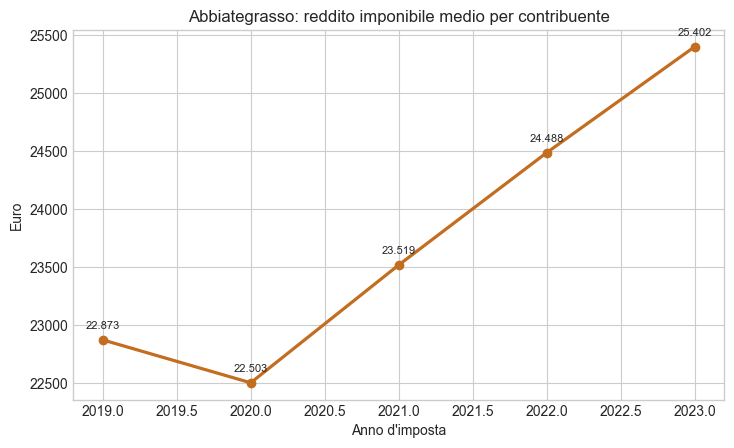

In [3]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
ax.plot(
    abb['anno_imposta'],
    abb['reddito_imponibile_medio_per_contribuente_eur'],
    marker='o',
    linewidth=2.3,
    color='#c26d1f',
)
ax.set_title('Abbiategrasso: reddito imponibile medio per contribuente')
ax.set_xlabel("Anno d'imposta")
ax.set_ylabel('Euro')
ax.tick_params(axis='x', rotation=0)

for _, row in abb.iterrows():
    ax.annotate(
        f"{row['reddito_imponibile_medio_per_contribuente_eur']:,.0f}".replace(',', '.'),
        (row['anno_imposta'], row['reddito_imponibile_medio_per_contribuente_eur']),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=8,
    )

trend_fig_path = save_figure(fig, 'abbiategrasso_irpef_trend.png')
trend_fig_path

Lettura minima del trend:

- Abbiategrasso scende leggermente nel `2020`, poi cresce in modo abbastanza lineare fino al `2023`
- il reddito imponibile medio per contribuente passa da circa `22,9 mila` a `25,4 mila euro`
- nello stesso periodo i contribuenti crescono da circa `23,3 mila` a `23,9 mila`


## 2. Benchmark leggero sui sei comuni

Usiamo lo stesso set del primo filone:

- Abbiategrasso
- Magenta
- Vigevano
- Buccinasco
- Rozzano
- Corsico

Qui guardiamo il `2023`, cosi' la posizione relativa resta leggibile.


In [4]:
benchmark_2023 = df[df['anno_imposta'] == 2023].copy()
benchmark_2023 = benchmark_2023.sort_values('reddito_imponibile_medio_per_contribuente_eur', ascending=False)
benchmark_2023[['comune_label', 'reddito_imponibile_medio_per_contribuente_eur', 'addizionale_comunale_media_per_contribuente_eur', 'numero_contribuenti']]

,comune_label,reddito_imponibile_medio_per_contribuente_eur,addizionale_comunale_media_per_contribuente_eur,numero_contribuenti
25,Buccinasco,30433.277233,226.404996,20178.0
27,Magenta,27126.832913,205.926270,18649.0
24,Abbiategrasso,25401.992183,185.593947,23923.0
29,Vigevano,23385.888937,173.709403,45785.0
26,Corsico,23313.797115,171.874056,26345.0
28,Rozzano,23208.568704,173.529026,30042.0


WindowsPath('C:/Users/gabry/OneDrive/Desktop/dataciviclab-workspace/abbiategrasso-data-notes/figures/abbiategrasso_irpef_benchmark_2023.png')

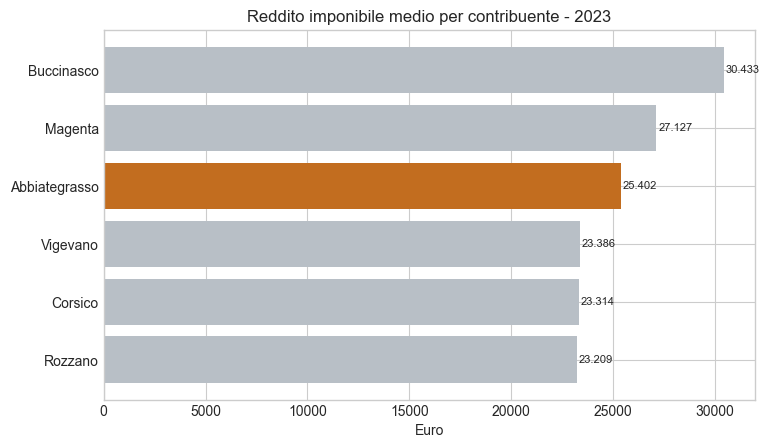

In [5]:
plot_df = benchmark_2023.sort_values('reddito_imponibile_medio_per_contribuente_eur', ascending=True)
colors = ['#c26d1f' if comune == 'Abbiategrasso' else '#b8bfc6' for comune in plot_df['comune_label']]

fig, ax = plt.subplots(figsize=(8.4, 4.8))
bars = ax.barh(plot_df['comune_label'], plot_df['reddito_imponibile_medio_per_contribuente_eur'], color=colors)
ax.set_title('Reddito imponibile medio per contribuente - 2023')
ax.set_xlabel('Euro')
ax.set_ylabel('')

for bar, comune, value in zip(bars, plot_df['comune_label'], plot_df['reddito_imponibile_medio_per_contribuente_eur']):
    label = f"{value:,.0f}".replace(',', '.')
    ax.text(value + 90, bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=8)

benchmark_fig_path = save_figure(fig, 'abbiategrasso_irpef_benchmark_2023.png')
benchmark_fig_path

Lettura minima del benchmark 2023:

- Buccinasco resta nettamente sopra il gruppo
- Magenta sta sopra Abbiategrasso, ma con un distacco molto piu' contenuto
- Abbiategrasso si colloca a meta' alta del set: sopra Vigevano, Corsico e Rozzano, sotto Buccinasco e Magenta


## 3. Caveat minimi

Questa non e' una misura di ricchezza complessiva dei residenti.

- il dataset riguarda i contribuenti IRPEF, non tutti i residenti
- il reddito imponibile medio non coincide con patrimonio, costo della vita o benessere complessivo
- il benchmark dei sei comuni resta una scelta di leggibilita' territoriale, non un matching rigoroso


## 4. Prossimo passo

Il confronto piu' stretto sul Sud Ovest milanese e' gia' disponibile in:

- `notebooks/abbiategrasso_irpef_sud_ovest_v1.ipynb`
- `notes/abbiategrasso-irpef-sud-ovest-milanese.md`

Se il filone continua a reggere, il passo successivo sensato e' uno di questi:

- confrontare meglio reddito imponibile medio e crescita dei contribuenti
- capire se il benchmark largo e quello territoriale vadano tenuti entrambi anche nei filoni futuri
